In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.features.feature_engineer.rpm_features import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s21 = pd.read_csv('data/raw/season_stats/S21.csv').sort_values(by='GAME_DATE')
p21 = pd.read_csv('data/raw/playoff_stats/P21.csv').sort_values(by='GAME_DATE')
s21 = pd.concat([s21, p21])

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])
s26.sample(10)

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE
1248,25366,2025-26,1641796,Pelle Larsson,Pelle,1610612748,MIA,Miami Heat,22500124,2025-10-28T00:00:00,MIA vs. CHA,W,30.733333,6,10,0.600,3,6,0.500,2,2,1.000,1,4,5,3,0,1,0,1,0,3,17,7,30.5,0,0,30.0,1,30:44,1,120.9,123.6,123.6,117.1,115.5,115.5,3.8,8.1,8.1,0.115,0.00,21.4,0.029,0.118,0.074,0.0,0.0,0.750,0.781,0.141,0.140,112.17,111.67,93.06,111.67,0.133,72,6.0,10.0,G,4.92,2.40,3.0,8.0,11.0,51.0,0.0,1.0,38.0,2.0,2.0,1.000,4.0,8.0,0.500,1.0,3.0,0.333,52,96,0.542,20,45,0.444,20,22,0.909,8,29,37,34,11.0,8,2,3,16,18,144,27.0,132.5,133.3,107.2,109.3,25.3,24.0,0.654,3.09,22.4,0.217,0.731,0.490,0.102,0.646,0.681,108.9,107.5,89.58,108,0.595,1610612766,CHA,Charlotte Hornets,40,90,0.444,18,45,0.400,19,23,0.826,9,32,41,26,18.0,9,3,2,18,16,117,-27.0,107.2,109.3,132.5,133.3,-25.3,-24.0,0.650,1.44,17.8,0.269,0.783,0.510,0.168,0.544,0.584,108.9,107.5,89.58,107,0.405,0,SG,24.0
5414,21124,2025-26,1627759,Jaylen Brown,Jaylen,1610612738,BOS,Boston Celtics,22500277,2025-11-23T00:00:00,BOS vs. ORL,W,37.433333,14,26,0.538,2,6,0.333,5,7,0.714,1,3,4,8,1,1,0,2,3,5,35,12,53.8,0,0,51.0,1,37:26,1,143.6,139.7,139.7,119.0,124.4,124.4,24.5,15.4,15.4,0.286,8.00,21.1,0.036,0.067,0.055,2.6,2.6,0.577,0.602,0.353,0.363,100.92,100.02,83.35,100.02,0.148,78,14.0,26.0,F,4.37,2.58,3.0,8.0,11.0,64.0,0.0,0.0,33.0,8.0,14.0,0.571,6.0,12.0,0.500,6.0,7.0,0.857,53,88,0.602,15,33,0.455,17,22,0.773,7,30,37,29,5.0,6,8,4,21,17,138,9.0,144.2,142.3,128.3,133.0,15.9,9.3,0.547,5.80,21.8,0.194,0.582,0.429,0.052,0.688,0.706,98.1,97.0,80.83,97,0.548,1610612753,ORL,Orlando Magic,47,100,0.470,16,38,0.421,19,24,0.792,18,26,44,33,8.0,3,4,8,17,21,129,-9.0,128.3,133.0,144.2,142.3,-15.9,-9.3,0.702,4.13,21.6,0.418,0.806,0.571,0.082,0.550,0.583,98.1,97.0,80.83,97,0.452,0,SF,29.0
26088,445,2025-26,1642266,Ja'Kobe Walter,Ja'Kobe,1610612761,TOR,Toronto Raptors,22501176,2026-04-10T00:00:00,TOR @ NYK,L,29.450000,5,9,0.556,4,7,0.571,1,2,0.500,0,2,2,1,1,1,0,0,2,1,15,-20,20.9,0,0,24.0,1,29:27,1,90.4,91.1,91.1,120.9,124.6,124.6,-30.5,-33.5,-33.5,0.067,1.00,8.3,0.000,0.095,0.043,8.3,8.4,0.778,0.759,0.186,0.186,93.82,92.09,76.74,92.09,0.100,56,5.0,9.0,G,4.35,2.25,0.0,3.0,3.0,40.0,0.0,0.0,28.0,1.0,1.0,1.000,4.0,8.0,0.500,0.0,0.0,0.000,36,73,0.493,10,25,0.400,13,20,0.650,7,25,32,24,18.0,7,0,0,24,16,95,-17.0,102.4,102.

In [3]:
res = []
for df in [s21, s22, s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)
    
    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["REB_PER_MIN"] = df["REB"] / df["MIN"].replace(0, np.nan)
    df["OREB_PER_MIN"] = df["OREB"] / df["MIN"].replace(0, np.nan)
    df["DREB_PER_MIN"] = df["DREB"] / df["MIN"].replace(0, np.nan)
    df['ORBC_PER_MIN'] = df['ORBC'] / df['MIN'].replace(0, np.nan)
    df['DRBC_PER_MIN'] = df['DRBC'] / df['MIN'].replace(0, np.nan)
    df['RBC_PER_MIN'] = df['RBC'] / df['MIN'].replace(0, np.nan)

    df = rpm_features(df)

    df['TEAM_REB_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_REB_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df['REB_PER_MIN_TREND'] = df['REB_PER_MIN_5_ewm'] - df['REB_PER_MIN_10_ewm']
    df['RPM_SEASON_STD'] = df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.expanding().std().shift(1))

    df["GP"] = df.groupby("PLAYER_ID").cumcount()

    df['POSITION_ENC'] = LabelEncoder().fit_transform(df['POS'])

    # df['MIN_REG'] = df['MIN'].clip(upper=48)
    # df = df[(df['MIN_REG'] >= 15) | (df['STARTING'] == 1)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(167488, 297)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,STARTING,REB_PER_MIN,OREB_PER_MIN,DREB_PER_MIN,ORBC_PER_MIN,DRBC_PER_MIN,RBC_PER_MIN,MIN_roll3,PLUS_MINUS_roll3,REB_roll3,REB_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,REB_PER_MIN_roll3,OREB_PER_MIN_roll3,DREB_PER_MIN_roll3,MIN_roll5,PLUS_MINUS_roll5,REB_roll5,REB_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,REB_PER_MIN_roll5,OREB_PER_MIN_roll5,DREB_PER_MIN_roll5,MIN_roll10,PLUS_MINUS_roll10,REB_roll10,REB_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,REB_PER_MIN_roll10,OREB_PER_MIN_roll10,DREB_PER_MIN_roll10,REB_PER_MIN_3_ewm,OREB_PER_MIN_3_ewm,DREB_PER_MIN_3_ewm,ORBC_PER_MIN_3_ewm,DRBC_PER_MIN_3_ewm,RBC_PER_MIN_3_ewm,REB_PER_MIN_5_ewm,OREB_PER_MIN_5_ewm,DREB_PER_MIN_5_ewm,ORBC_PER_MIN_5_ewm,DRBC_PER_MIN_5_ewm,RBC_PER_MIN_5_ewm,REB_PER_MIN_10_ewm,OREB_PER_MIN_10_ewm,DREB_PER_MIN_10_ewm,ORBC_PER_MIN_10_ewm,DRBC_PER_MIN_10_ewm,RBC_PER_MIN_10_ewm,MIN_lag1,PLUS_MINUS_lag1,REB_lag1,REB_PCT_lag1,OREB_PCT_lag1,DREB_PCT_lag1,STARTING_lag1,MIN_lag2,PLUS_MINUS_lag2,REB_lag2,REB_PCT_lag2,OREB_PCT_lag2,DREB_PCT_lag2,STARTING_lag2,STARTER_ROLL10_PCT,MIN_season_avg,REB_season_avg,REB_PCT_season_avg,OREB_PCT_season_avg,DREB_PCT_season_avg,REB_PER_MIN_season_avg,OREB_PER_MIN_season_avg,DREB_PER_MIN_season_avg,ORBC_PER_MIN_season_avg,DRBC_PER_MIN_season_avg,RBC_PER_MIN_season_avg,TEAM_PACE_roll10,TEAM_REB_roll10,TEAM_FG_PCT_roll10,TEAM_FGA_roll10,TEAM_FG3A_roll10,MIN_share_proxy_roll10,REB_share_proxy_roll10,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,REB_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_FG_PCT_roll5,OPP_FG_PCT_roll10,OPP_FGA_roll5,OPP_FGA_roll10,OPP_FG3A_roll5,OPP_FG3A_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_POSS_ALLOWED,TEAM_REB_ALLOWED,TEAM_OREB_ALLOWED,TEAM_DREB_ALLOWED,OPP_TEAM_POSS_ALLOWED,OPP_TEAM_REB_ALLOWED,OPP_TEAM_OREB_ALLOWED,OPP_TEAM_DREB_ALLOWED,TEAM_REB_PER_MIN_RANK_L10,MEDIAN_REB_PER_MIN_L10,REB_PER_MIN_TREND,RPM_SEASON_STD,GP,POSITION_ENC
167483,2025-26,1643257,Jayson Kent,Jayson,1610612757,POR,Portland Trail Blazers,22500985,2026-03-16,POR @ BKN,W,3.15,1,1,1.000,0,0,0.0,0,0,0.0,0,1,1,0,0,0,0,0,0,0,2,2,3.2,0,0,3.0,1,3:09,1,150.0,150.0,150.0,140.0,116.7,116.7,10.0,33.3,33.3,0.0,0.0,0.0,0.0,0.500,0.500,0.0,0.0,1.000,1.000,0.167,0.167,83

In [ ]:
# df.to_csv('data/processed/training/S26_TRAINING_RPM.csv', index=False)

In [ ]:
# start = df.columns.get_loc("RBC_PER_MIN") + 1
# cols_after = df.columns[start:]
# df_after = df.loc[:, cols_after]
# df_after.drop(columns=['MIN_REG'], inplace=True)
# RPM_FEATURES = list(df_after.columns)
# RPM_FEATURES

In [17]:
RPM_FEATURES = [
    'REB_PER_MIN_season_avg',
    'RBC_PER_MIN_10_ewm',
    'POSITION_ENC',
    'REB_PER_MIN_roll5',
    'REB_season_avg',
    'OPP_TEAM_REB_ALLOWED',
    'EXPECTED_PACE',
    'RPM_SEASON_STD',
    'STARTING',
]

In [18]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[RPM_FEATURES + ["REB_PER_MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[RPM_FEATURES]
y = ppm_df["REB_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
#Best params: {'n_estimators': 1344, 'max_depth': 3, 'learning_rate': 0.0199208375412252, 'subsample': 0.6525095024077675, 'colsample_bytree': 0.7424913081435832, 'reg_alpha': 3.890568820995351, 'reg_lambda': 0.007402304793152013, 'min_child_weight': 10}
XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1344,
    max_depth          = 3,
    learning_rate      = 0.0199208375412252,
    subsample          = 0.6525095024077675,
    colsample_bytree   = 0.7424913081435832,
    reg_alpha          = 3.890568820995351,
    reg_lambda         = 4.755281357016035,
    min_child_weight   = 10,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Data shape: {X.shape}")
tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Data shape: (126199, 9)
TSCV fold 1                    | MAE: 0.068 | R²: 0.433 | 80% Coverage: 79.7%
TSCV fold 2                    | MAE: 0.067 | R²: 0.436 | 80% Coverage: 80.2%
TSCV fold 3                    | MAE: 0.067 | R²: 0.425 | 80% Coverage: 80.0%
TSCV fold 4                    | MAE: 0.069 | R²: 0.413 | 80% Coverage: 79.6%
TSCV fold 5                    | MAE: 0.070 | R²: 0.402 | 80% Coverage: 79.6%

TimeSeriesSplit Summary
  MAE      : 0.068 ± 0.001
  R²       : 0.422  ± 0.013
  Coverage : 79.8% ± 0.2%  (target ~80%)


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")   

WF fold 1 (2023-05-12 00:00:00 → 2024-02-07 00:00:00) | MAE: 0.068 | R²: 0.420 | 80% Coverage: 79.7%
WF fold 2 (2024-02-07 00:00:00 → 2024-11-24 00:00:00) | MAE: 0.068 | R²: 0.417 | 80% Coverage: 80.1%
WF fold 3 (2024-11-24 00:00:00 → 2025-03-19 00:00:00) | MAE: 0.069 | R²: 0.431 | 80% Coverage: 79.0%
WF fold 4 (2025-03-19 00:00:00 → 2025-12-31 00:00:00) | MAE: 0.070 | R²: 0.383 | 80% Coverage: 79.3%

Walk-Forward Summary
  MAE      : 0.069 ± 0.001
  R²       : 0.413  ± 0.018
  Coverage : 79.5% ± 0.4%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2023-05-12 00:00:00 → 2024-02-07 00:00:00) 0.068  
  WF fold 2 (2024-02-07 00:00:00 → 2024-11-24 00:00:00) 0.068  
  WF fold 3 (2024-11-24 00:00:00 → 2025-03-19 00:00:00) 0.069  
  WF fold 4 (2025-03-19 00:00:00 → 2025-12-31 00:00:00) 0.070  


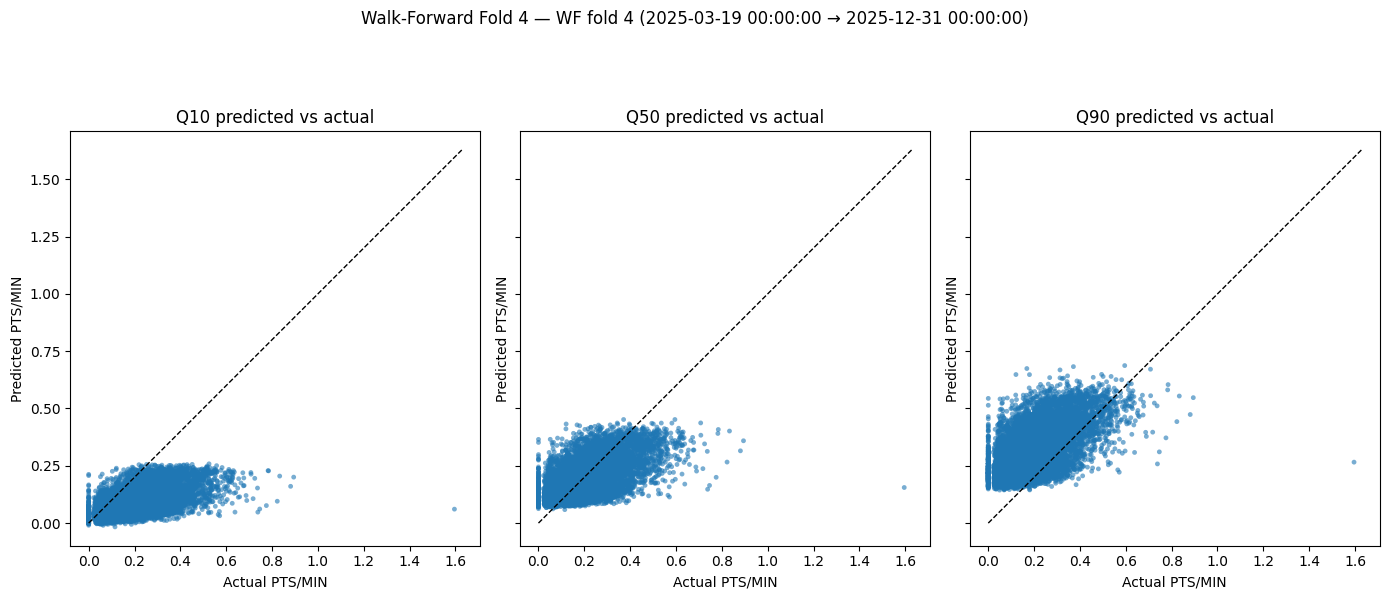

Coverage per quantile (should match quantile value):
  Q10: 10.5%  (target 10%, delta +0.5%)
  Q50: 50.8%  (target 50%, delta +0.8%)
  Q90: 89.8%  (target 90%, delta -0.2%)

80% interval width (Q10→Q90):
  mean : 0.22 min
  median: 0.21 min
  std  : 0.05 min


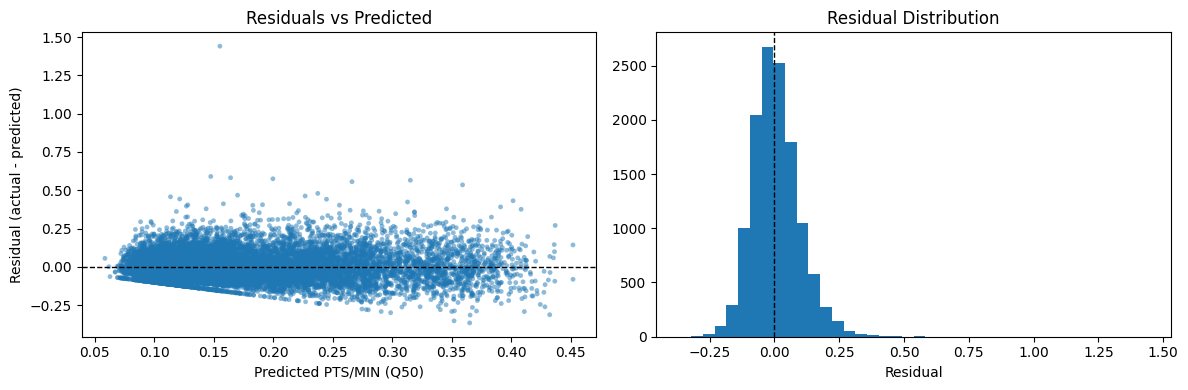


Residual summary:
  mean bias : +0.007 min  (close to 0 = unbiased)
  std       : 0.092 min


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/MIN")
    ax.set_ylabel("Predicted PTS/MIN")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted PTS/MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")


── q_0.10 ──


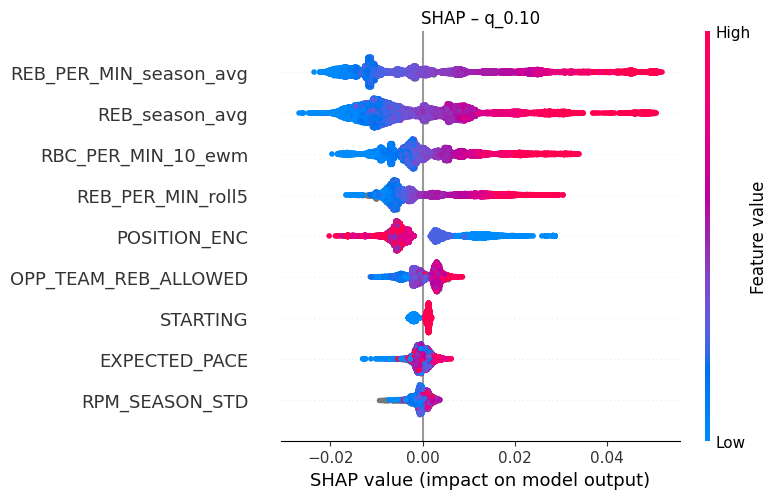


── q_0.50 ──


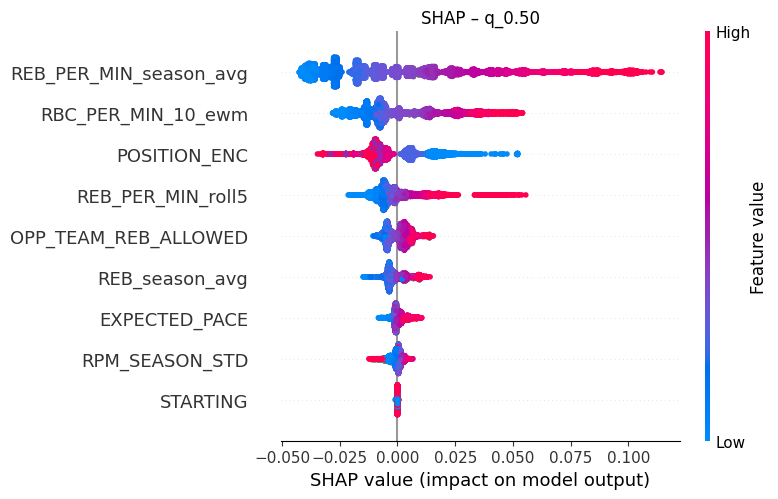


── q_0.90 ──


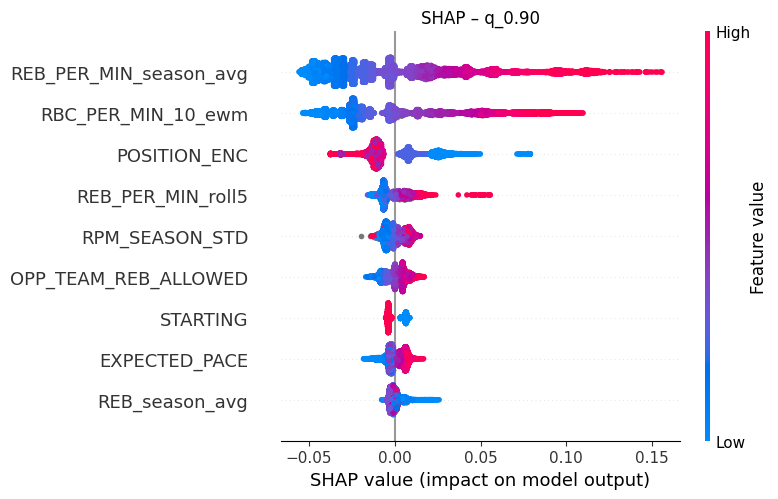

In [21]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

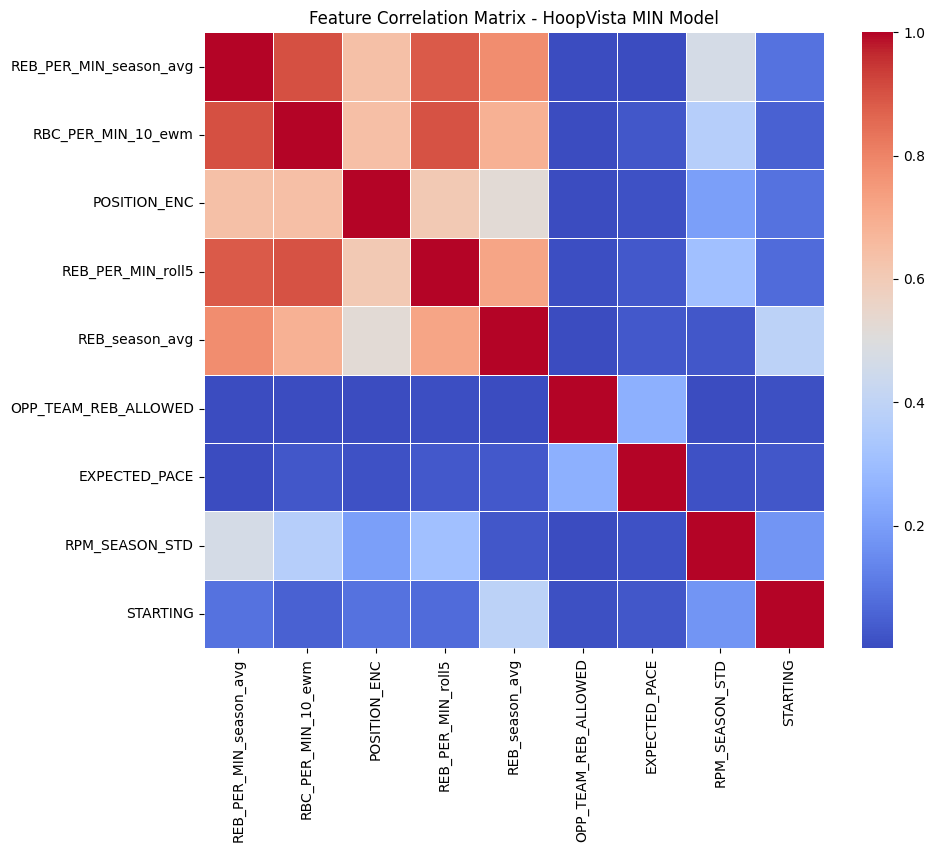

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [22]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, RPM_FEATURES)
correlated_features

In [23]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   RPM_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"rpm_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_ppm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to rpm_quantile_xgb_2025-12-31.joblib
Loaded model MAE: 0.070
Trained on data up to: 2025-03-19 00:00:00
Validated on data up to: 2025-12-31 00:00:00
